<a href="https://colab.research.google.com/github/Diegoaz279/PRACTICA_FINAL_IA/blob/main/PRACTICA_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Librerías

import pandas as pd
import matplotlib.pyplot as plt

In [7]:
#Crear dataset

datos = [
    [52,1,10,18,"estable",78,65,"manana",0],
    [48,1,8,22,"estable",74,60,"tarde",0],
    [55,1,12,15,"estable",80,68,"tarde",0],
    [44,2,9,25,"compartido",69,58,"noche",0],
    [60,1,11,12,"estable",82,70,"manana",0],
    [50,1,7,20,"estable",76,62,"tarde",0],
    [46,2,13,28,"compartido",71,57,"noche",0],
    [58,1,9,16,"estable",84,72,"tarde",0],
    [49,1,10,19,"estable",73,61,"manana",0],
    [53,2,8,24,"compartido",77,64,"tarde",0],

    [11,4,1,91,"vpn",98,10,"madrugada",1],
    [9,3,0,87,"vpn",96,8,"madrugada",1],
    [13,4,2,89,"desconocido",97,12,"noche",1],
    [10,3,1,94,"vpn",99,9,"madrugada",1],
    [12,4,1,90,"desconocido",95,11,"noche",1],
    [8,3,0,93,"vpn",100,7,"madrugada",1],
    [14,4,2,88,"vpn",97,13,"noche",1],
    [10,3,1,92,"desconocido",98,9,"madrugada",1],
    [12,4,0,86,"vpn",96,10,"madrugada",1],
    [9,3,1,95,"vpn",99,8,"noche",1],
]

columnas = [
    "tiempo_total_examen_min",
    "numero_intentos",
    "numero_cambios_respuesta",
    "coincidencia_patrones_pct",
    "ip_dispositivo_codificado",
    "porcentaje_aciertos",
    "tiempo_promedio_pregunta_seg",
    "horario_realizacion",
    "sospechoso"
]

df = pd.DataFrame(datos, columns=columnas)
df = pd.concat([df]*8, ignore_index=True)

df.to_csv("fraude_academico.csv", index=False)
print("Dataset guardado correctamente")



Dataset guardado correctamente


In [8]:
#Cargar y ver datos

df = pd.read_csv("fraude_academico.csv")

print(df.head())
print("\nCantidad de registros:", len(df))
print("\nValores nulos:")
print(df.isnull().sum())
print("\nClases:")
print(df["sospechoso"].value_counts())

   tiempo_total_examen_min  numero_intentos  numero_cambios_respuesta  \
0                       52                1                        10   
1                       48                1                         8   
2                       55                1                        12   
3                       44                2                         9   
4                       60                1                        11   

   coincidencia_patrones_pct ip_dispositivo_codificado  porcentaje_aciertos  \
0                         18                   estable                   78   
1                         22                   estable                   74   
2                         15                   estable                   80   
3                         25                compartido                   69   
4                         12                   estable                   82   

   tiempo_promedio_pregunta_seg horario_realizacion  sospechoso  
0                   

In [9]:
#Exploración

print(df.describe(include="all"))

        tiempo_total_examen_min  numero_intentos  numero_cambios_respuesta  \
count                160.000000       160.000000                160.000000   
unique                      NaN              NaN                       NaN   
top                         NaN              NaN                       NaN   
freq                        NaN              NaN                       NaN   
mean                  31.150000         2.400000                  5.300000   
std                   20.744083         1.203768                  4.619891   
min                    8.000000         1.000000                  0.000000   
25%                   10.750000         1.000000                  1.000000   
50%                   29.000000         2.500000                  4.500000   
75%                   50.500000         3.250000                  9.250000   
max                   60.000000         4.000000                 13.000000   

        coincidencia_patrones_pct ip_dispositivo_codificado  \


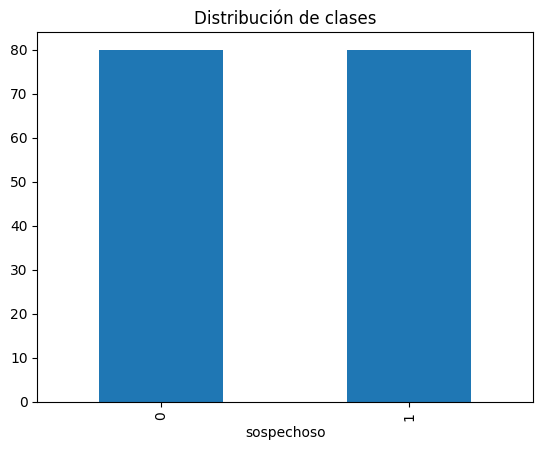

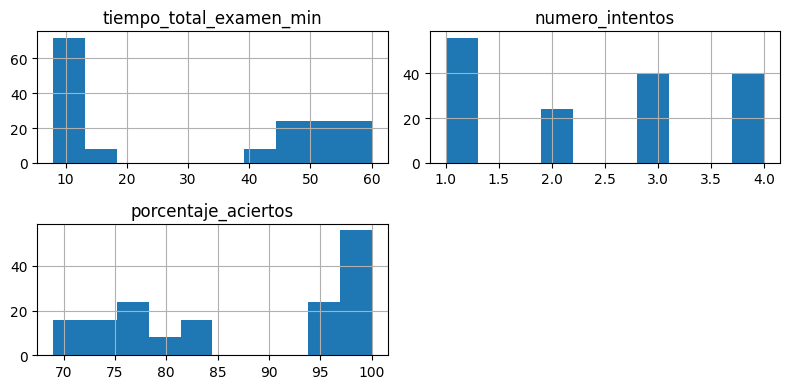

In [10]:
#Gráficas

df["sospechoso"].value_counts().plot(kind="bar")
plt.title("Distribución de clases")
plt.show()

df[["tiempo_total_examen_min","numero_intentos","porcentaje_aciertos"]].hist(figsize=(8,4))
plt.tight_layout()
plt.show()

In [11]:
#Instalacion e importacion

!pip install tensorflow -q

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [13]:
#Separar variables

df = pd.read_csv("fraude_academico.csv")

X = df.drop("sospechoso", axis=1)
y = df["sospechoso"]

num_cols = [
    "tiempo_total_examen_min",
    "numero_intentos",
    "numero_cambios_respuesta",
    "coincidencia_patrones_pct",
    "porcentaje_aciertos",
    "tiempo_promedio_pregunta_seg"
]

cat_cols = [
    "ip_dispositivo_codificado",
    "horario_realizacion"
]

In [14]:
#Dividir datos

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validación:", X_val.shape)
print("Test:", X_test.shape)

In [14]:
#Preprocesamiento

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train = pre.fit_transform(X_train).toarray()
X_val = pre.transform(X_val).toarray()
X_test = pre.transform(X_test).toarray()

print("Datos transformados:", X_train.shape)

In [ ]:
#Crear modelo

model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

In [ ]:
#Entrenar modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8,
    verbose=1
)

In [ ]:
#Importar métricas

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
#Graficar entrenamiento

plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.title("Pérdida del modelo")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.title("Precisión del modelo")
plt.legend()
plt.show()

In [ ]:
#Evaluar modelo
pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, pred))



In [ ]:
#Matriz de confusión
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Sospechoso"]).plot()
plt.title("Matriz de confusión")
plt.show()

In [ ]:
#Probar caso nuevo
nuevo = pd.DataFrame([{
    "tiempo_total_examen_min": 10,
    "numero_intentos": 4,
    "numero_cambios_respuesta": 1,
    "coincidencia_patrones_pct": 92,
    "ip_dispositivo_codificado": "vpn",
    "porcentaje_aciertos": 98,
    "tiempo_promedio_pregunta_seg": 9,
    "horario_realizacion": "madrugada"
}])

nuevo_prep = pre.transform(nuevo).toarray()
resultado = model.predict(nuevo_prep)[0][0]

print("Probabilidad de sospecha:", resultado)
print("Clasificación:", "Sospechoso" if resultado > 0.5 else "Normal")

In [ ]:
#Reflexión ética
print("""
Reflexión ética:
Este sistema no debe usarse para acusar automáticamente a un estudiante.
Solo funciona como apoyo para detectar casos sospechosos que deben ser revisados
por una persona. El modelo puede cometer errores o falsos positivos.
""")